In [4]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

In [3]:
%pip install --upgrade pip
%pip install tensorflow

  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/5d/95/6b5cb3461ea5673ba0995989746db58eb18b91b54dbf331e72f569540946/pip-26.1.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.2.1
    Uninstalling pip-23.2.1:
      Successfully uninstalled pip-23.2.1
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 1.9 MB/s  0:02:12m0:00:0100:04m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 2.8 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 1.8 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 2.9 MB/s  0:00:08m0:00

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print('TensorFlow version:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.21.0


In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Размер x_train:', x_train.shape)
print('Размер y_train:', y_train.shape)
print('Размер x_test:', x_test.shape)
print('Размер y_test:', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Размер x_train: (60000, 28, 28)
Размер y_train: (60000,)
Размер x_test: (10000, 28, 28)
Размер y_test: (10000,)


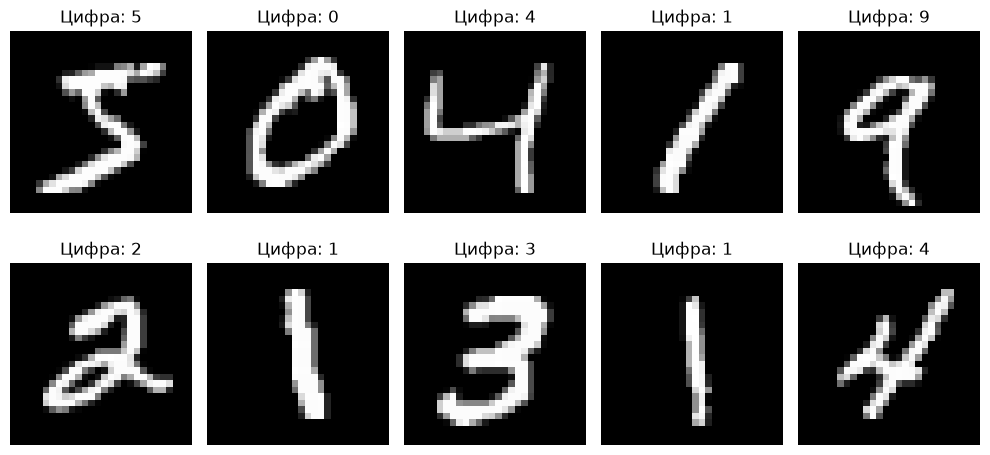

In [8]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Цифра: {y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print('Минимальное значение:', x_train.min())
print('Максимальное значение:', x_train.max())


Минимальное значение: 0.0
Максимальное значение: 1.0


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9050 - loss: 0.3224 - val_accuracy: 0.9675 - val_loss: 0.1117
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9603 - loss: 0.1323 - val_accuracy: 0.9735 - val_loss: 0.0901
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9719 - loss: 0.0919 - val_accuracy: 0.9770 - val_loss: 0.0780
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0716 - val_accuracy: 0.9782 - val_loss: 0.0737
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9813 - loss: 0.0606 - val_accuracy: 0.9793 - val_loss: 0.0683
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9833 - loss: 0.0519 - val_accuracy: 0.9818 - val_loss: 0.0656
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9864 - loss: 0.0422 - val_accuracy: 0.9808 - val_loss: 0.0674
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0362 - val_accuracy: 0.

In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

Test loss: 0.0650
Test accuracy: 0.9802
Test accuracy: 98.02%


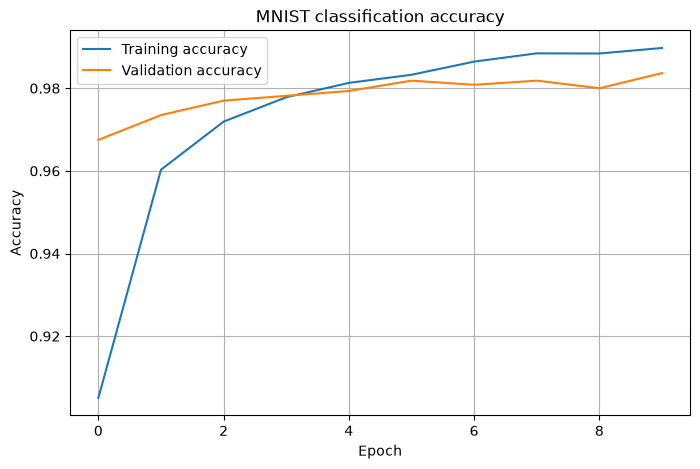

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MNIST classification accuracy')
plt.legend()
plt.grid()
plt.show()

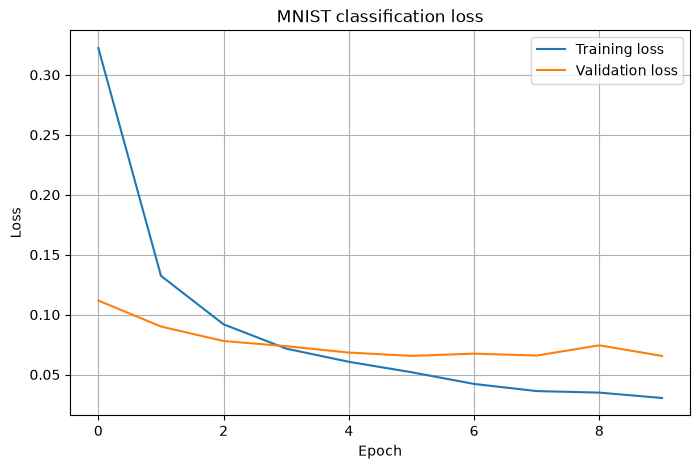

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MNIST classification loss')
plt.legend()
plt.grid()
plt.show()

In [16]:
predictions = model.predict(x_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

print('Первые 10 реальных классов:   ', y_test[:10])
print('Первые 10 прогнозов модели:', predicted_classes[:10])

Первые 10 реальных классов:    [7 2 1 0 4 1 4 9 5 9]
Первые 10 прогнозов модели: [7 2 1 0 4 1 4 9 5 9]


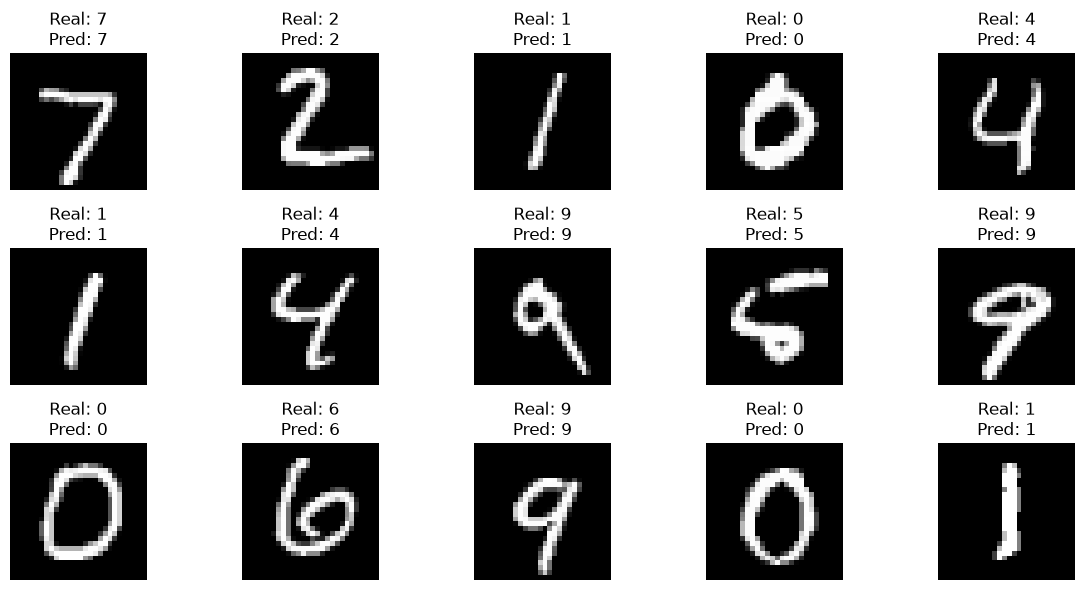

In [17]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f'Real: {y_test[i]}\nPred: {predicted_classes[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Количество ошибок: 198
Доля ошибок: 0.0198


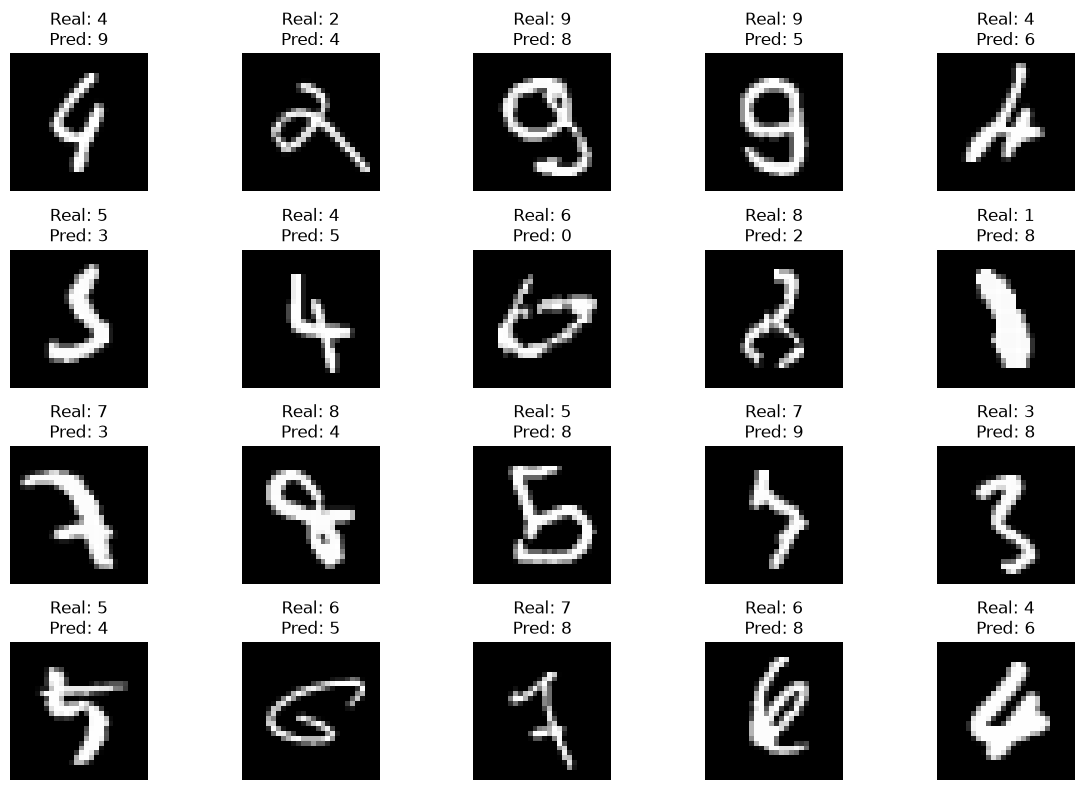

In [18]:
wrong_indices = np.where(predicted_classes != y_test)[0]

print('Количество ошибок:', len(wrong_indices))
print('Доля ошибок:', len(wrong_indices) / len(y_test))

plt.figure(figsize=(12, 8))

for position, index in enumerate(wrong_indices[:20]):
    plt.subplot(4, 5, position + 1)
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f'Real: {y_test[index]}\nPred: {predicted_classes[index]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

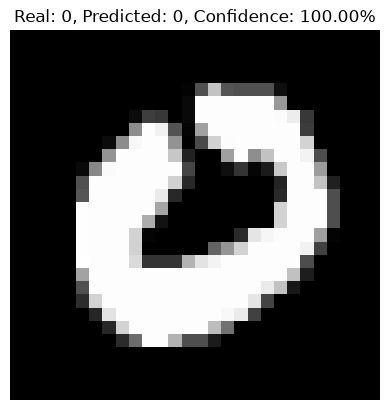

In [19]:
image_index = 25

single_image = x_test[image_index]
single_prediction = model.predict(single_image[np.newaxis, ...], verbose=0)
predicted_digit = np.argmax(single_prediction)
confidence = np.max(single_prediction)

plt.imshow(single_image, cmap='gray')
plt.title(
    f'Real: {y_test[image_index]}, '
    f'Predicted: {predicted_digit}, '
    f'Confidence: {confidence:.2%}'
)
plt.axis('off')
plt.show()